# Lab: Polynomial Regression with scikit-learn

In the [theory notes](./02_polynomial_regression_theory.md), we learned *what* Polynomial Regression is and *why* linear models sometimes fall short when the true relationship between variables is non-linear. In the [implementation file](./03_polynomial_regression_implementation.py), we built it from scratch to see the mechanics under the hood.

**Now it's time to see how the real world does it.** In practice, we use scikit-learn's `PolynomialFeatures` transformer together with `LinearRegression` to capture non-linear relationships effortlessly. In this lab, we will learn how to:

1.  Load and prepare a dataset for polynomial modeling.
2.  Understand how `PolynomialFeatures` transforms our features.
3.  Build a Polynomial Regression model using scikit-learn.
4.  Inspect and interpret the model's coefficients.
5.  Visualize the model to extract business insights.

---

## 1. The Dataset

We'll continue with the **Advertising** dataset we used in the linear regression labs. It contains data from 200 different markets, showing spending on TV, Radio, and Newspaper ads, alongside resulting Sales.

From the [Multiple Linear Regression Lab](../02_linear_and_logistic_regression/07_multiple_linear_regression_lab.ipynb), we learned two important things about this data:

- **`TV` and `Radio`** are strong, statistically significant predictors of sales.
- **`Newspaper`** is not a significant predictor.

We also noticed that a straight-line model couldn't fully capture the relationship — suggesting a non-linear approach might work better. That's exactly what we'll explore here.

Let's start by importing our libraries and loading the data.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["figure.dpi"] = 150

In [2]:
# Load the data
data = pd.read_csv("../data/raw/advertising.csv")
data.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


---

## 2. Preparing the Data

Based on what we learned in the multiple linear regression lab, we'll use only `TV` and `Radio` as our features, and `Sales` as our target.

In [3]:
# Keep TV, Radio, and Sales
sales_df = data[["TV", "Radio", "Sales"]].copy()
sales_df.columns = [col.lower() for col in sales_df.columns]

# Separate features and target
X = sales_df[["tv", "radio"]]
y = sales_df["sales"]

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (200, 2)
Shape of y: (200,)


---

## 3. Understanding `PolynomialFeatures`

This is the key concept in this lab. The trick behind polynomial regression in scikit-learn is that **we don't need a special model** — we just transform our features into polynomial combinations and then feed them to the same `LinearRegression` we already know.

For two features $x_1$ (TV) and $x_2$ (Radio), `PolynomialFeatures(degree=2)` generates:

$$[x_1, \; x_2, \; x_1^2, \; x_1 x_2, \; x_2^2]$$

That last term, $x_1 x_2$, is especially interesting — it's the **interaction term** that captures how TV and Radio spending *together* affect sales (synergy effect).

Let's see this in action:

In [4]:
# Create the polynomial feature transformer
poly = PolynomialFeatures(degree=2, include_bias=False)

# Transform the features
X_poly = poly.fit_transform(X)

# Let's see what happened
print(f"Original features: {list(X.columns)}")
print(f"Original shape:    {X.shape}")
print()
print(f"Polynomial features: {poly.get_feature_names_out()}")
print(f"Polynomial shape:    {X_poly.shape}")
print()
print("First 5 rows of transformed features:")
pd.DataFrame(X_poly, columns=poly.get_feature_names_out()).head()

Original features: ['tv', 'radio']
Original shape:    (200, 2)

Polynomial features: ['tv' 'radio' 'tv^2' 'tv radio' 'radio^2']
Polynomial shape:    (200, 5)

First 5 rows of transformed features:


,tv,radio,tv^2,tv radio,radio^2
0,230.1,37.8,52946.01,8697.78,1428.84
1,44.5,39.3,1980.25,1748.85,1544.49
2,17.2,45.9,295.84,789.48,2106.81
3,151.5,41.3,22952.25,6256.95,1705.69
4,180.8,10.8,32688.64,1952.64,116.64


We went from 2 features to 5. The transformer created:

| New Feature | Meaning |
|---|---|
| `tv` | Original TV spend |
| `radio` | Original Radio spend |
| `tv^2` | Squared TV spend (captures diminishing returns) |
| `tv radio` | Interaction between TV and Radio (captures synergy) |
| `radio^2` | Squared Radio spend |

Now the model can learn curved relationships because it has access to these higher-order terms.

---

## 4. Building the Model

With our polynomial features ready, building the model is exactly the same as building a standard linear regression — just `fit()` on the transformed features.

In [5]:
# Create and train the model on the polynomial features
model = LinearRegression()
model.fit(X_poly, y)

print("Model trained successfully!")

Model trained successfully!


### 4.1. Inspecting the Learned Parameters

Our polynomial regression model has learned one coefficient for each of the 5 polynomial features, plus an intercept. The full equation is:

$$\text{Sales} = \theta_0 + \theta_1 \cdot \text{TV} + \theta_2 \cdot \text{Radio} + \theta_3 \cdot \text{TV}^2 + \theta_4 \cdot \text{TV} \cdot \text{Radio} + \theta_5 \cdot \text{Radio}^2$$

Let's print them:

In [6]:
# Print intercept and coefficients
print(f"Intercept (θ₀): {model.intercept_:.6f}")
print()

feature_names = poly.get_feature_names_out()
for name, coef in zip(feature_names, model.coef_):
    print(f"Coefficient for {name:12s}: {coef:.6f}")

Intercept (θ₀): 5.194442

Coefficient for tv          : 0.050993
Coefficient for radio       : 0.026540
Coefficient for tv^2        : -0.000110
Coefficient for tv radio    : 0.001075
Coefficient for radio^2     : 0.000186


#### 📌 Why Direct Coefficient Interpretation is Tricky

Unlike a simple linear model where each coefficient has a straightforward meaning ("$1,000 more on TV → X more units sold"), polynomial models are harder to interpret directly because:

- The effect of TV on Sales now depends on *how much* TV is already being spent (due to the TV² term).
- The effect of TV also depends on *how much* Radio is being spent (due to the TV × Radio interaction term).

So instead of reading individual coefficients, we'll use **visualization** to understand the model's behavior. This is the standard approach for interpreting non-linear models.

---

## 5. Making Predictions

When making predictions with a polynomial model, remember the **two-step process**:
1.  Transform the new data using the *same* `PolynomialFeatures` object.
2.  Predict using the model.

In [7]:
# Predict sales for some specific TV and Radio spend combinations
new_data = pd.DataFrame({
    "tv":    [50, 100, 150, 200, 250],
    "radio": [20,  30,  35,  40,  45]
})

# Step 1: Transform with the SAME poly object (use .transform(), NOT .fit_transform())
new_data_poly = poly.transform(new_data)

# Step 2: Predict
predictions = model.predict(new_data_poly)

# Display results
result = new_data.copy()
result["predicted_sales"] = np.round(predictions, 2)
print(result.to_string(index=False))

 tv  radio  predicted_sales
 50     20             9.15
100     30            13.38
150     35            17.17
200     40            20.96
250     45            24.74


> ⚠️ **Important:** Always use `.transform()` on new data, not `.fit_transform()`. The `PolynomialFeatures` object was already fit on the training data. Using `.fit_transform()` on new data would refit the transformer, which in this case produces the same result, but it's a bad habit — with other transformers like scalers, it would give wrong results.

---

## 6. Visualizing the Model's Behavior

Since we can't easily read the coefficients, let's visualize what the model learned. We'll answer two key business questions:

1.  **Diminishing Returns:** Is there a point where increasing TV spend stops being effective?
2.  **Synergy Effects:** How does spending on Radio amplify the impact of TV?

### 6.1. Diminishing Returns of TV Spend

To isolate the effect of TV, we'll hold Radio constant at its median value and vary TV across its range.

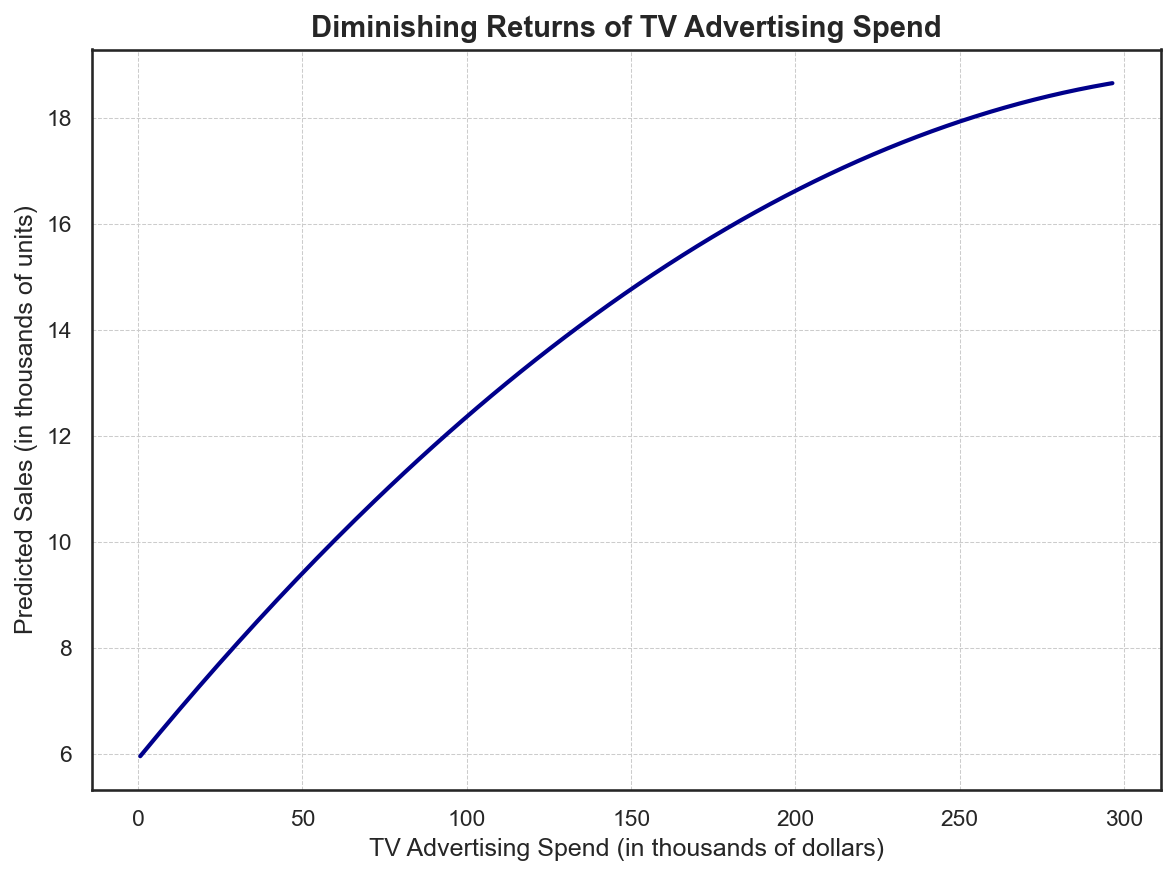

In [8]:
# Hold Radio at its median, vary TV
radio_median = X["radio"].median()
tv_range = np.linspace(X["tv"].min(), X["tv"].max(), 200)

# Create scenario DataFrame
scenario = pd.DataFrame({"tv": tv_range, "radio": radio_median})

# Transform and predict
scenario_poly = poly.transform(scenario)
predicted_sales = model.predict(scenario_poly)

# Plot
plt.figure()
plt.plot(tv_range, predicted_sales, color="darkblue", linewidth=2)
plt.title("Diminishing Returns of TV Advertising Spend", fontsize=14, fontweight="bold")
plt.xlabel("TV Advertising Spend (in thousands of dollars)")
plt.ylabel("Predicted Sales (in thousands of units)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

The curve clearly shows a non-linear relationship:

- At **lower levels** of TV spend, the curve is steep — each additional dollar yields a significant increase in sales.
- At **higher levels** of TV spend, the curve flattens — the benefit of each additional dollar shrinks.

This is the **diminishing returns** effect that a straight-line model could never capture.

### 6.2. The Synergy Effect: TV × Radio

Now let's see how *different levels* of Radio spending change the relationship between TV and Sales.

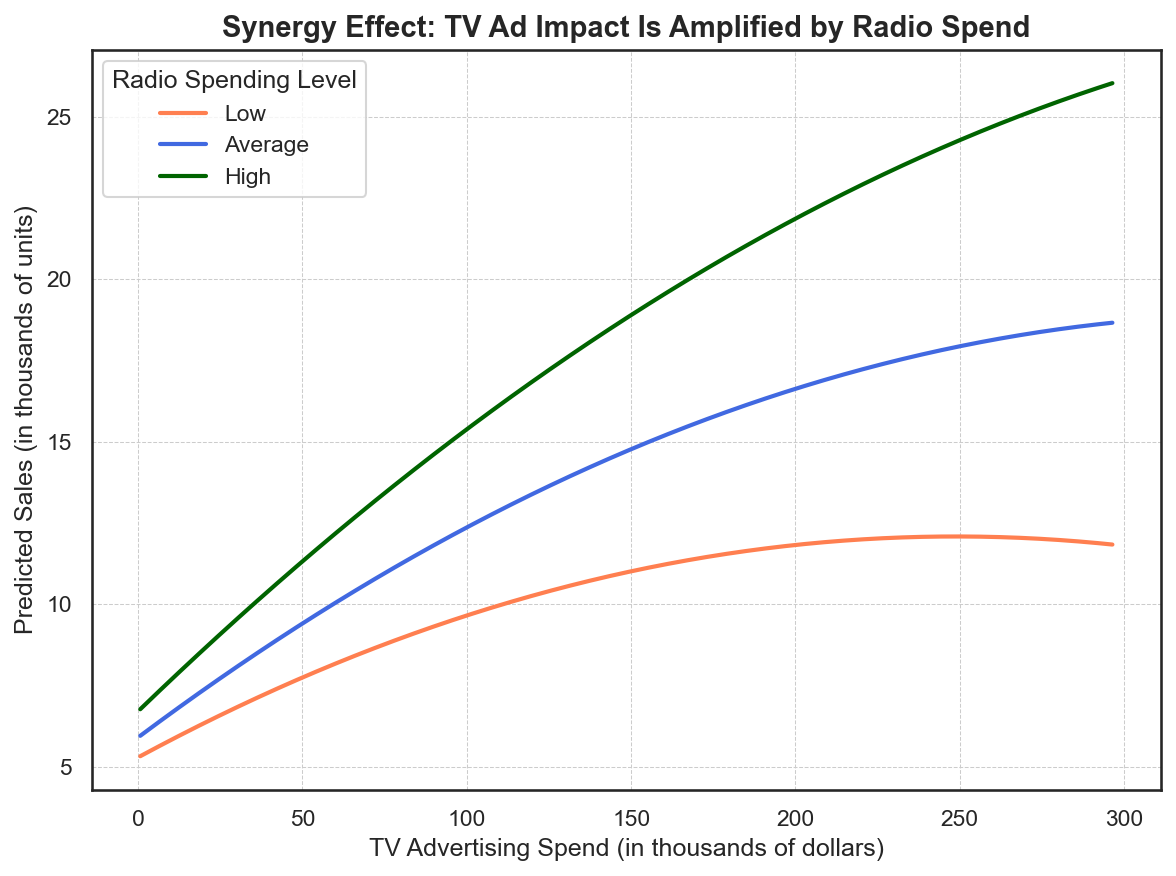

In [9]:
# Define Low, Average, and High radio spending levels
radio_low  = X["radio"].quantile(0.10)   # 10th percentile
radio_high = X["radio"].quantile(0.90)   # 90th percentile

levels = {"Low": radio_low, "Average": radio_median, "High": radio_high}
colors = {"Low": "coral", "Average": "royalblue", "High": "darkgreen"}

# Plot one curve per radio level
plt.figure()
for level_name, radio_value in levels.items():
    df = pd.DataFrame({"tv": tv_range, "radio": radio_value})
    df_poly = poly.transform(df)
    preds = model.predict(df_poly)
    plt.plot(tv_range, preds, label=level_name, color=colors[level_name], linewidth=2)

plt.title("Synergy Effect: TV Ad Impact Is Amplified by Radio Spend", fontsize=14, fontweight="bold")
plt.xlabel("TV Advertising Spend (in thousands of dollars)")
plt.ylabel("Predicted Sales (in thousands of units)")
plt.legend(title="Radio Spending Level", loc="upper left")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

This is one of the most powerful insights the polynomial model gives us:

- The lines are **not parallel**. When Radio spend is high (green), the impact of each additional TV dollar is dramatically larger than when Radio spend is low (coral).
- This means TV and Radio **amplify each other**. A coordinated campaign using both channels is far more effective than spending on either one alone.

This kind of **interaction effect** is exactly what the $\text{TV} \times \text{Radio}$ term in our polynomial features captures.

---

## Summary

In this lab, we learned how to use scikit-learn to build a Polynomial Regression model. Here's what we covered:

| Step | What We Did | Key scikit-learn API |
|------|-------------|---------------------|
| Transform features | Created polynomial & interaction terms | `PolynomialFeatures(degree=2)` |
| Fit to data | Applied the transformation | `poly.fit_transform(X)` |
| Train model | Fit a `LinearRegression` on transformed features | `model.fit(X_poly, y)` |
| Inspect | Read the intercept and coefficients | `model.intercept_`, `model.coef_` |
| Predict | Two-step: transform *then* predict | `poly.transform(X_new)` → `model.predict(...)` |
| Interpret | Visualized diminishing returns & synergy effects | `matplotlib` |

The key takeaway is that **Polynomial Regression in scikit-learn is just Linear Regression on engineered features**. The `PolynomialFeatures` transformer does the heavy lifting of generating squared and interaction terms, and the model learns the optimal weights for each.

---

**Next:** [Multi-Class Classification Theory](./05_multi-class_classification_theory.md)